In [1]:
import pandas as pd
import numpy as np

file_path = "Parquet data/"
file_name = "03.06_7" 

df = pd.read_parquet(f"{file_path}{file_name}.parquet")
# print(df.shape)
# print(df.dtypes)

In [2]:
VELOCITY_THRESHOLD = 60000 #30000
MIN_FRAMES = 100

summary = df.groupby("label").agg(
    n_points=("velocity", "size"),
    duration=("frame", lambda t: t.max() - t.min()),
    max_abs_v=("velocity", lambda v: v.abs().max()),
    frac_zero=("velocity", lambda v: (v == 0).mean()),
).reset_index()

valid_labels = summary[
    (summary["max_abs_v"] > VELOCITY_THRESHOLD)
    & (summary["n_points"] >= MIN_FRAMES)
]["label"].tolist()

# Cluster IDs are only meaningful within a frame, so count using both keys.
cluster_counts = df.groupby(["frame", "cluster_id"])["label"].transform("size")
df["cluster_size"] = np.where(df["cluster_id"].eq(-1), 1, cluster_counts)

print(f"{len(valid_labels)} of {summary.shape[0]} labels kept")
sub = df[df["label"].isin(valid_labels)].sort_values(["label", "frame"])
print(sub.shape)

2215 of 17483 labels kept
(12163914, 16)


In [3]:
# Save the filtered GUI-equivalent data.
sub.to_parquet(f"{file_name}_filtered.parquet", compression="zstd", index=False)

In [4]:
from matplotlib import pyplot as plt

results = {}
for lbl in valid_labels:
    track = sub[sub["label"] == lbl].sort_values("frame")
    results[lbl] = {
        "time": track["time"].to_numpy(),
        "velocity": track["velocity"].to_numpy(),
        "acceleration": track["acceleration"].to_numpy(),
        "cluster_id": track["cluster_id"].to_numpy(),
        "cluster_size": track["cluster_size"].to_numpy(),
        "x": track["x"].to_numpy(),
        "y": track["y"].to_numpy(),
    }

## Plot one traj vel and acc

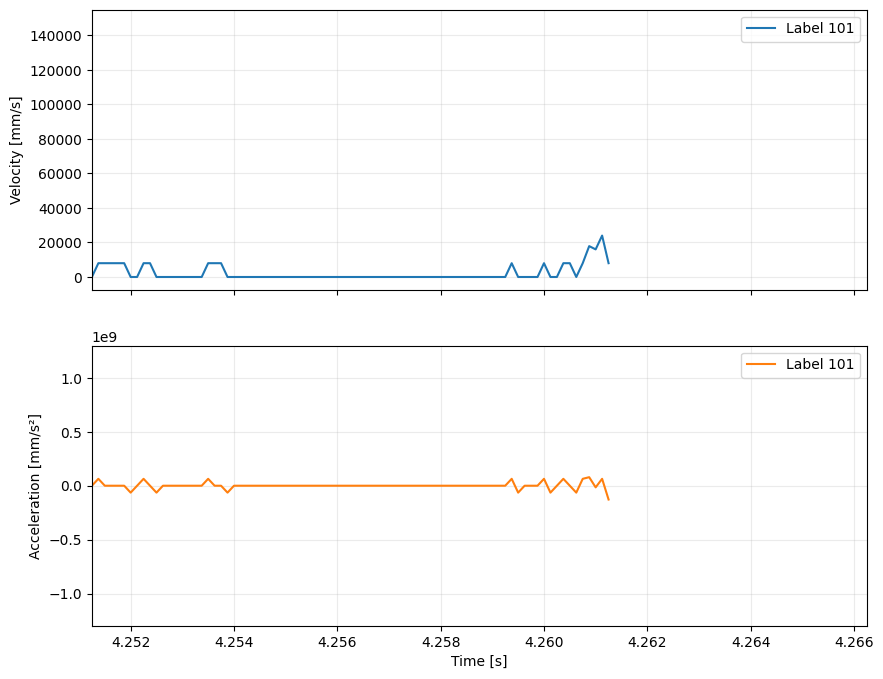

In [5]:
label_to_plot = 101
track_result = results[label_to_plot]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(
    track_result["time"],
    track_result["velocity"],
    label=f"Label {label_to_plot}",
)
axes[0].set_ylabel("Velocity [mm/s]")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    track_result["time"],
    track_result["acceleration"],
    label=f"Label {label_to_plot}",
    color="tab:orange",
)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Acceleration [mm/s²]")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[1].set_xlim(track_result["time"].max()-0.01, track_result["time"].max()+0.005)

plt.show()

# Normal acceleration / vel calcs

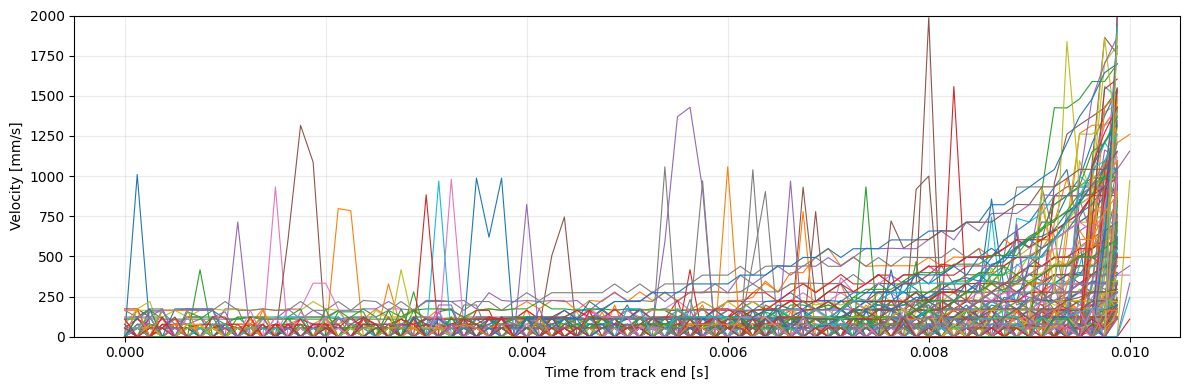

In [6]:
PIXEL_SIZE_MM = 0.006849
WINDOW_SECONDS = 0.01

filtered_vels = []
filtered_accs = []
calc_accs = []
weighed_accs = []
cluster_size_curves = []

# fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig, axes = plt.subplots(1, 1, figsize=(12, 4), sharex=True)

for label_to_plot, track_result in results.items():
    final_time = track_result["time"].max()
    indexes = track_result["time"] > final_time - WINDOW_SECONDS
    time = track_result["time"][indexes] - track_result["time"][indexes].min()

    #try to remove spiky things
    if track_result["velocity"][indexes].max() * PIXEL_SIZE_MM > 2000:
        continue
    elif track_result["velocity"][indexes][-1] * PIXEL_SIZE_MM < 100:
        continue

    vel_data = track_result["velocity"][indexes] * PIXEL_SIZE_MM
    filtered_vels.append(vel_data)
    filtered_accs.append(track_result["acceleration"][indexes] * PIXEL_SIZE_MM)

    calc_acc = np.gradient(vel_data, time)
    cluster_sizes = track_result["cluster_size"][indexes].astype(float)
    calc_accs.append(calc_acc)
    cluster_size_curves.append(cluster_sizes)
    weighed_accs.append(calc_acc * cluster_sizes)

    axes.plot(
        time,
        vel_data,
        linewidth=0.8,
        label=f"Label {label_to_plot}",
    )
    # axes[1].plot(
    #     time,
    #     track_result["acceleration"][indexes] * PIXEL_SIZE_MM,
    #     linewidth=0.8,
    #     label=f"Label {label_to_plot}",
    # )

if filtered_vels:
    common_length = min(
        min(map(len, filtered_vels)),
        min(map(len, filtered_accs)),
        min(map(len, calc_accs)),
        min(map(len, cluster_size_curves)),
        min(map(len, weighed_accs)),
    )
    filtered_vels = np.vstack(
        [vel_data[-common_length:] for vel_data in filtered_vels]
    )
    filtered_accs = np.vstack(
        [acc_data[-common_length:] for acc_data in filtered_accs]
    )
    calc_accs = np.vstack(
        [acc_data[-common_length:] for acc_data in calc_accs]
    )
    cluster_size_curves = np.vstack(
        [sizes[-common_length:] for sizes in cluster_size_curves]
    )
    weighed_accs = np.vstack(
        [acc_data[-common_length:] for acc_data in weighed_accs]
    )
    time = time[-common_length:]
else:
    filtered_vels = np.empty((0, 0))
    filtered_accs = np.empty((0, 0))
    calc_accs = np.empty((0, 0))
    cluster_size_curves = np.empty((0, 0))
    weighed_accs = np.empty((0, 0))

axes.set_ylabel("Velocity [mm/s]")
axes.set_ylim(0, 2000)
# axes[1].set_ylabel("Acceleration [mm/s²]")
axes.set_xlabel("Time from track end [s]")

# for ax in axes:
axes.grid(alpha=0.25)

# axes[0].legend(
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     fontsize="small",
#     ncol=2,
# )

plt.tight_layout()
plt.show()

# Filtering attempt based on position

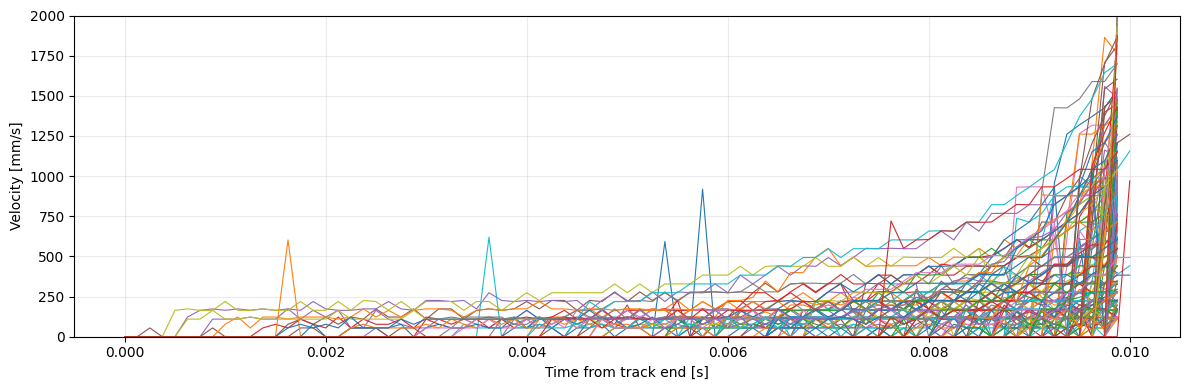

In [ ]:
from scipy.ndimage import median_filter

PIXEL_SIZE_MM = 0.006849
WINDOW_SECONDS = 0.01

filtered_vels = []
filtered_accs = []
calc_accs = []
weighed_accs = []
cluster_size_curves = []
displacements = []

# fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig, axes = plt.subplots(1, 1, figsize=(12, 4), sharex=True)

for label_to_plot, track_result in results.items():
    final_time = track_result["time"].max()
    indexes = track_result["time"] > final_time - WINDOW_SECONDS
    time = track_result["time"][indexes] - track_result["time"][indexes].min()

    #try to remove spiky things
    if track_result["velocity"][indexes].max() * PIXEL_SIZE_MM > 2000:
        continue
    elif track_result["velocity"][indexes][-1] * PIXEL_SIZE_MM < 100:
        continue

    vel_data = track_result["velocity"][indexes] * PIXEL_SIZE_MM
    filtered_accs.append(track_result["acceleration"][indexes] * PIXEL_SIZE_MM)

    # check vel data and pos to see if outlier 
    initial_pos = np.array([track_result["x"][indexes][0], track_result["y"][indexes][0]])
    pos_vec = np.array([track_result["x"][indexes], track_result["y"][indexes]])
    relative_pos = pos_vec - initial_pos[:, np.newaxis]
    rel_dist = np.linalg.norm(relative_pos, axis=0)
    
    # Compare each value with the local median.
    local_median = median_filter(vel_data, size=7, mode="nearest")
    spike_filter = np.abs(vel_data - local_median) < 200
    
    # Remove points belonging to short spikes.
    vel_data[~spike_filter] = 0

    dist_filter = rel_dist > 10
    vel_data[~dist_filter] = 0
    if np.all(vel_data == 0):
        continue
    filtered_vels.append(vel_data)

    calc_acc = np.gradient(vel_data, time)
    cluster_sizes = track_result["cluster_size"][indexes].astype(float)
    calc_accs.append(calc_acc)
    cluster_size_curves.append(cluster_sizes)
    weighed_accs.append(calc_acc * cluster_sizes)
    displacements.append(rel_dist)

    axes.plot(
        time,
        vel_data,
        linewidth=0.8,
        label=f"Label {label_to_plot}",
    )

if filtered_vels:
    common_length = min(
        min(map(len, filtered_vels)),
        min(map(len, filtered_accs)),
        min(map(len, calc_accs)),
        min(map(len, cluster_size_curves)),
        min(map(len, weighed_accs)),
        min(map(len, displacements)),
    )
    filtered_vels = np.vstack(
        [vel_data[-common_length:] for vel_data in filtered_vels]
    )
    filtered_accs = np.vstack(
        [acc_data[-common_length:] for acc_data in filtered_accs]
    )
    calc_accs = np.vstack(
        [acc_data[-common_length:] for acc_data in calc_accs]
    )
    cluster_size_curves = np.vstack(
        [sizes[-common_length:] for sizes in cluster_size_curves]
    )
    weighed_accs = np.vstack(
        [acc_data[-common_length:] for acc_data in weighed_accs]
    )
    time = time[-common_length:]
    displacements = np.vstack(
        [disp[-common_length:] for disp in displacements]
    )   
    # dist_filter = dist_filter[-common_length:]

else:
    filtered_vels = np.empty((0, 0))
    filtered_accs = np.empty((0, 0))
    calc_accs = np.empty((0, 0))
    cluster_size_curves = np.empty((0, 0))
    weighed_accs = np.empty((0, 0))
    displacements = np.empty((0, 0))
    # dist_filter = np.empty((0, 0))



axes.set_ylabel("Velocity [mm/s]")
axes.set_ylim(0, 2000)
axes.set_xlabel("Time from track end [s]")

axes.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# print(rel_dist)

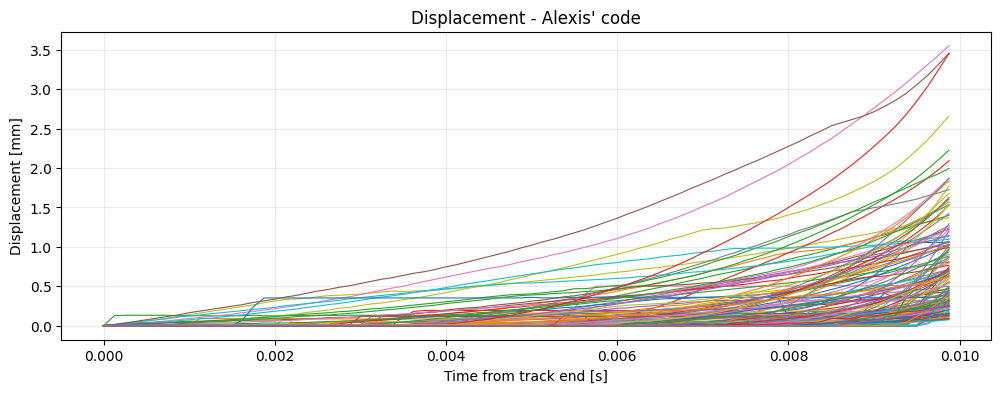

In [17]:
#  plot all displacement 
fig, axes = plt.subplots(1, 1, figsize=(12, 4), sharex=True)
for disp in displacements:
    axes.plot(
            time,
            disp*PIXEL_SIZE_MM,
            linewidth=0.8,
            label=f"Label {label_to_plot}",
        )

axes.set_ylabel("Displacement [mm]")
axes.set_xlabel("Time from track end [s]")
# axes.set_ylim(0, 750)
axes.title.set_text("Displacement - Alexis' code")

# for ax in axes:
axes.grid(alpha=0.25)

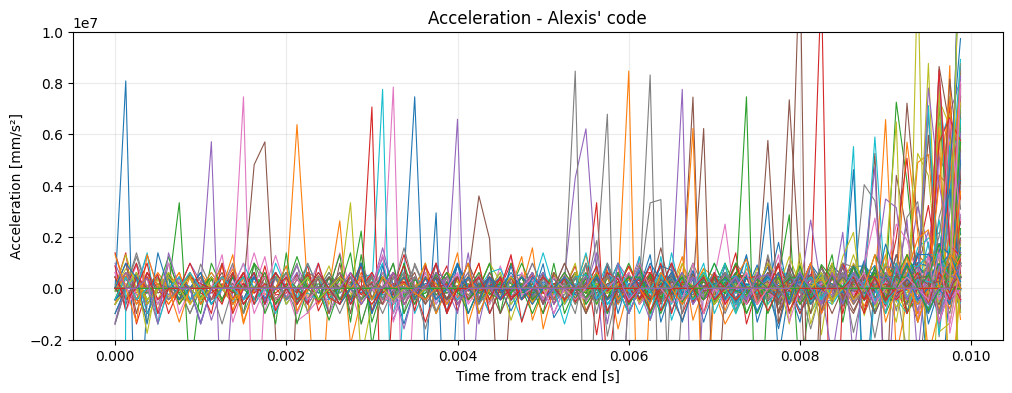

In [18]:
#  plot all accelerations 
fig, axes = plt.subplots(1, 1, figsize=(12, 4), sharex=True)
for acc in filtered_accs:
    axes.plot(
            time,
            acc,
            linewidth=0.8,
            label=f"Label {label_to_plot}",
        )

axes.set_ylabel("Acceleration [mm/s²]")
axes.set_xlabel("Time from track end [s]")
axes.set_ylim(-2e6,10e6)
axes.title.set_text("Acceleration - Alexis' code")

# for ax in axes:
axes.grid(alpha=0.25)

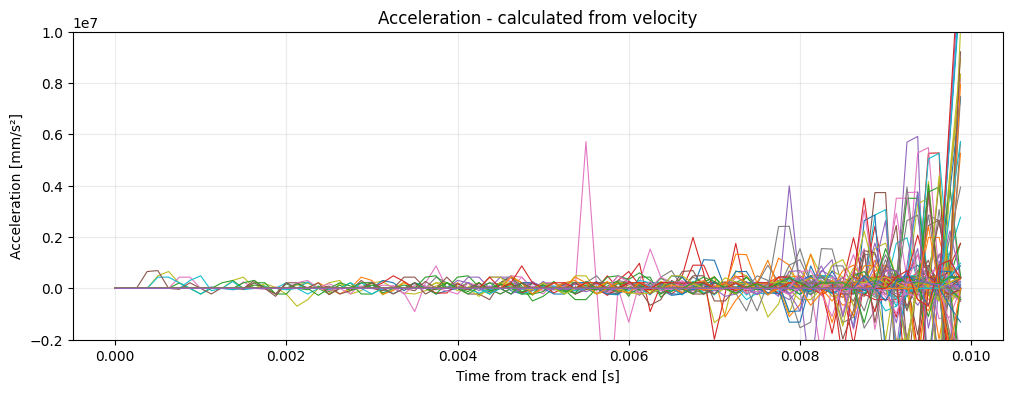

In [19]:
#  plot all calculated accelerations 
fig, axes = plt.subplots(1, 1, figsize=(12, 4), sharex=True)
for acc in calc_accs:
    axes.plot(
            time,
            acc,
            linewidth=0.8,
            label=f"Label {label_to_plot}",
        )

axes.set_ylabel("Acceleration [mm/s²]")
axes.set_xlabel("Time from track end [s]")
axes.set_ylim(-2e6,10e6)
axes.title.set_text("Acceleration - calculated from velocity")

# for ax in axes:
axes.grid(alpha=0.25)

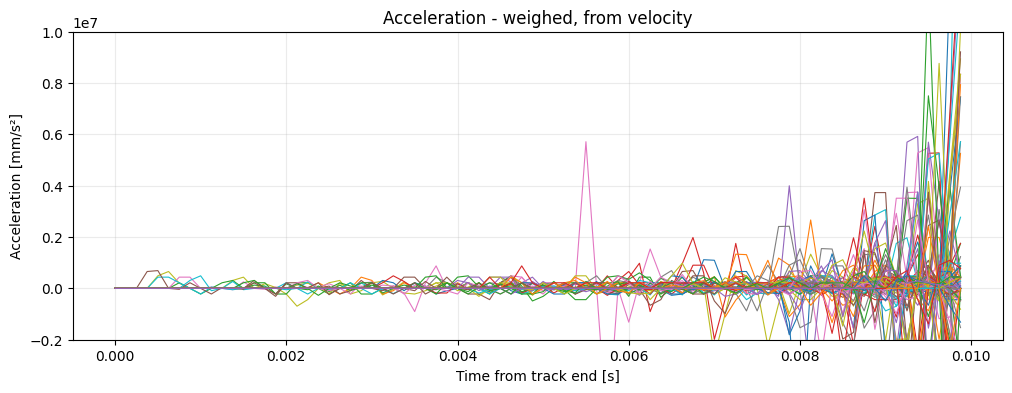

In [20]:
# Plotting weighed accelerations
fig, axes = plt.subplots(1, 1, figsize=(12, 4), sharex=True)
for acc in weighed_accs:
    axes.plot(
            time,
            acc,
            linewidth=0.8,
            label=f"Label {label_to_plot}",
        )

axes.set_ylabel("Acceleration [mm/s²]")
axes.set_xlabel("Time from track end [s]")
axes.set_ylim(-2e6,10e6)
axes.title.set_text("Acceleration - weighed, from velocity")

# for ax in axes:
axes.grid(alpha=0.25)

Total vel curves used: 145


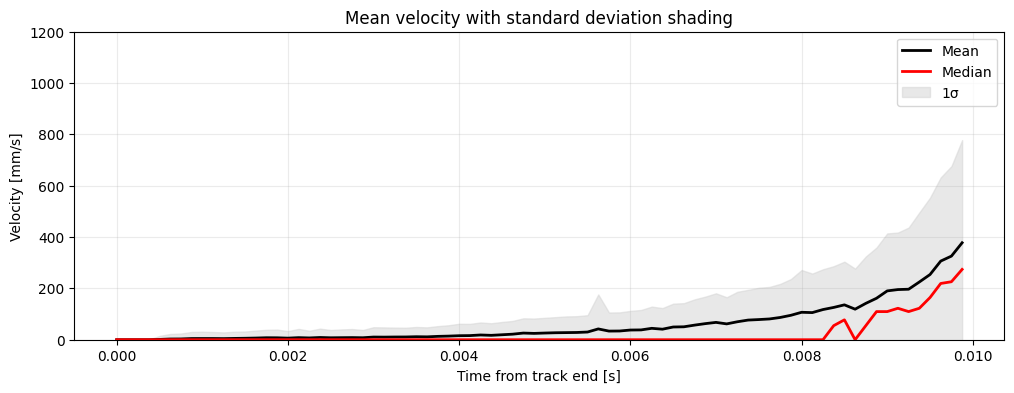

In [21]:
#find mean/std velocity progression of filtered_vels
mean_vel_vec = np.nanmean(filtered_vels, axis=0)
median_vel_vec = np.nanmedian(filtered_vels, axis=0)
std_vel = np.std(filtered_vels, axis=0)

# plot mean velocity with std shading
fig, axes = plt.subplots(1, 1, figsize=(12, 4), sharex=True)
axes.plot(
    time,
    mean_vel_vec,
    color='black',
    linewidth=2,
    label='Mean',
)

axes.plot(
    time,
    median_vel_vec,
    color='red',
    linewidth=2,
    label='Median',
)

axes.fill_between(
    time,
    mean_vel_vec - std_vel,
    mean_vel_vec + std_vel,
    color='lightgray',
    alpha=0.5,
    label='1σ',
)

axes.set_ylabel("Velocity [mm/s]")
axes.set_ylim(0, 1200)
axes.set_xlabel("Time from track end [s]")
axes.grid(alpha=0.25)
axes.legend()
axes.title.set_text("Mean velocity with standard deviation shading")

print(f"Total vel curves used: {len(filtered_vels)}")


Total acc curves used:  145


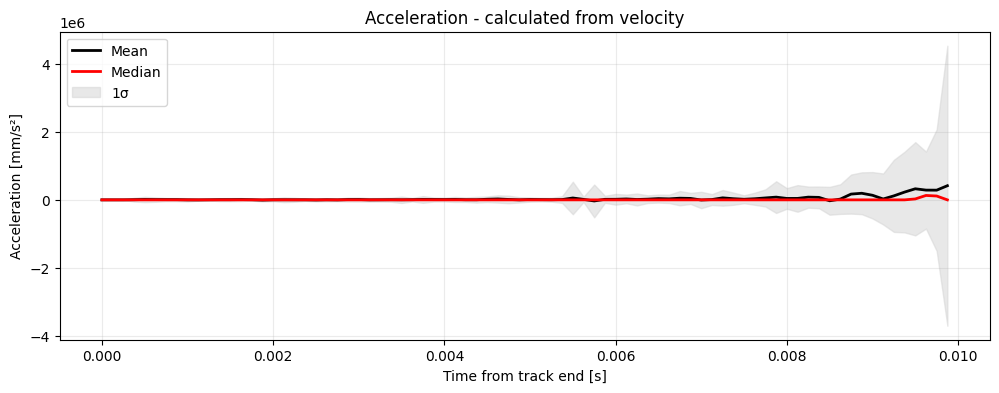

In [22]:
#find mean/std velocity progression of calc_accs
mean_acc_vec = np.nanmean(calc_accs, axis=0)
median_acc_vec = np.nanmedian(calc_accs, axis=0)
std_acc = np.std(calc_accs, axis=0)

# plot mean velocity with std shading
fig, axes = plt.subplots(1, 1, figsize=(12, 4), sharex=True)
axes.plot(
    time,
    mean_acc_vec,
    color='black',
    linewidth=2,
    label='Mean',
)
axes.plot(
    time,
    median_acc_vec,
    color='red',
    linewidth=2,
    label='Median',
)

axes.fill_between(
    time,
    mean_acc_vec - std_acc,
    mean_acc_vec + std_acc,
    color='lightgray',
    alpha=0.5,
    label='1σ',
)

axes.set_ylabel("Acceleration [mm/s²]")
# axes.set_ylim(-0.5e6, 2e6)
axes.set_xlabel("Time from track end [s]")
axes.grid(alpha=0.25)
axes.legend()
axes.title.set_text("Acceleration - calculated from velocity")

print("Total acc curves used: ", len(calc_accs))

Total acc curves used:  145


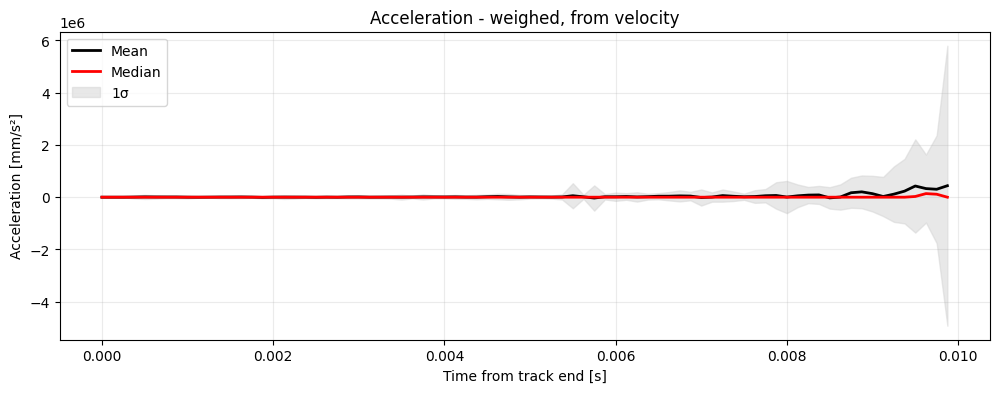

In [23]:
#find mean/std velocity progression of weighed_accs
mean_acc_vec = np.mean(weighed_accs, axis=0)
median_acc_vec = np.median(weighed_accs, axis=0)
std_acc = np.std(weighed_accs, axis=0)

# plot mean velocity with std shading
fig, axes = plt.subplots(1, 1, figsize=(12, 4), sharex=True)
axes.plot(
    time,
    mean_acc_vec,
    color='black',
    linewidth=2,
    label='Mean',
)
axes.plot(
    time,
    median_acc_vec,
    color='red',
    linewidth=2,
    label='Median',
)
axes.fill_between(
    time,
    mean_acc_vec - std_acc,
    mean_acc_vec + std_acc,
    color='lightgray',
    alpha=0.5,
    label='1σ',
)

axes.set_ylabel("Acceleration [mm/s²]")
# axes.set_ylim(-0.5e6, 2e6)
axes.set_xlabel("Time from track end [s]")
axes.grid(alpha=0.25)
axes.title.set_text("Acceleration - weighed, from velocity")
axes.legend()

print("Total acc curves used: ", len(calc_accs))

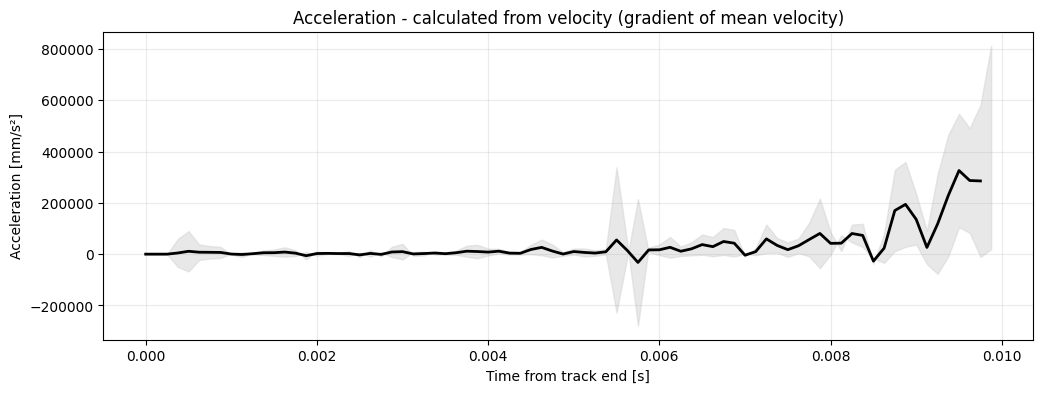

In [24]:
mean_accel_vec = np.gradient(mean_vel_vec, time)
acc_std = np.gradient(std_vel, time)
# note:gradient returns same amount of vals unlike diff() but last val looks weird so just removed from plot

fig, axes = plt.subplots(1, 1, figsize=(12, 4), sharex=True)
axes.plot(
    time[:-1],
    mean_accel_vec[:-1],
    color='black',
    linewidth=2,
    label='Mean',
)
axes.fill_between(
    time,
    mean_accel_vec - acc_std,
    mean_accel_vec + acc_std,
    color='lightgray',
    alpha=0.5,
    label='1σ',
)

axes.set_ylabel("Acceleration [mm/s²]")
# axes.set_ylim(0, 1200)
axes.set_xlabel("Time from track end [s]")
axes.grid(alpha=0.25)
axes.title.set_text("Acceleration - calculated from velocity (gradient of mean velocity)")

In [25]:
# check mean cluster size 
mean_cluster_size = np.mean(cluster_size_curves, axis=1)
print(mean_cluster_size)


[1.0125 1.     1.05   1.     1.     1.     1.     1.     1.     1.
 1.     1.0125 1.     1.     1.     1.0125 1.     1.     1.0375 1.
 1.025  1.     1.     1.0125 1.05   1.0125 1.0125 1.05   1.025  1.
 1.025  1.0125 1.     1.0125 1.     1.0125 1.     1.     1.0125 1.
 1.0375 1.     1.2    1.0375 1.25   1.     1.     1.025  1.     1.
 1.0375 1.     1.     1.     1.     1.     1.     1.025  1.125  1.0125
 1.05   1.0125 1.0125 1.0125 1.     1.     1.     1.     1.     1.
 1.     1.     1.0125 1.     1.025  1.0125 1.0375 1.05   1.     1.025
 1.0125 1.     1.     1.     1.     1.1125 1.     1.05   1.075  1.
 1.025  1.05   1.525  1.025  1.0125 1.025  1.     1.0125 1.0125 1.
 1.     1.     1.     1.0125 1.0125 1.0125 1.     1.0375 1.     1.0125
 1.     1.075  1.2875 1.0125 1.     1.0125 1.0625 1.0125 1.     1.0125
 1.3375 1.     1.05   1.0125 1.     1.0125 1.0625 1.0125 1.0375 1.0125
 1.0125 1.     1.0125 1.     1.0125 1.3375 1.2875 1.     1.     1.05
 1.     1.025  1.     1.1875 1.0125]
